<a href="https://colab.research.google.com/github/Daksh-create349/Image-Analysing-Model/blob/main/Accurate.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

# 1. Setup Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# 2. Data Augmentation (Crucial for 90%+ Accuracy)
stats = ((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(*stats),
])

# 3. Load CIFAR-10 Dataset
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=0)

# 4. Define ResNet9 Architecture
def conv_block(in_channels, out_channels, pool=False):
    layers = [nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
              nn.BatchNorm2d(out_channels),
              nn.ReLU(inplace=True)]
    if pool: layers.append(nn.MaxPool2d(2))
    return nn.Sequential(*layers)

class ResNet9(nn.Module):
    def __init__(self, in_channels=3, num_classes=10):
        super().__init__()
        self.conv1 = conv_block(in_channels, 64)
        self.conv2 = conv_block(64, 128, pool=True)
        self.res1 = nn.Sequential(conv_block(128, 128), conv_block(128, 128))
        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)
        self.res2 = nn.Sequential(conv_block(512, 512), conv_block(512, 512))
        self.classifier = nn.Sequential(nn.MaxPool2d(4), nn.Flatten(), nn.Dropout(0.2), nn.Linear(512, num_classes))

    def forward(self, xb):
        out = self.conv1(xb)
        out = self.conv2(out)
        out = self.res1(out) + out  # Residual connection
        out = self.conv3(out)
        out = self.conv4(out)
        out = self.res2(out) + out  # Residual connection
        return self.classifier(out)

model = ResNet9().to(device)
print("Model and Data ready!")

Using device: cuda


100%|██████████| 170M/170M [00:17<00:00, 9.91MB/s]


Model and Data ready!


In [ ]:
# 5. Hyperparameters
epochs = 20
max_lr = 0.01
grad_clip = 0.1
weight_decay = 1e-4
optimizer = optim.Adam(model.parameters(), max_lr, weight_decay=weight_decay)
sched = optim.lr_scheduler.OneCycleLR(optimizer, max_lr, epochs=epochs, steps_per_epoch=len(trainloader))
criterion = nn.CrossEntropyLoss()

# 6. Training Loop
for epoch in range(epochs):
    model.train()
    train_loss = 0
    loop = tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}")

    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping to prevent exploding gradients
        nn.utils.clip_grad_value_(model.parameters(), grad_clip)

        optimizer.step()
        sched.step()

        train_loss += loss.item()
        loop.set_postfix(loss=train_loss/len(trainloader))

    # Validation Accuracy Check
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1} Accuracy: {100 * correct / total:.2f}%")

Epoch 1/20: 100%|██████████| 391/391 [00:42<00:00,  9.25it/s, loss=1.45]


Epoch 1 Accuracy: 54.72%


Epoch 2/20: 100%|██████████| 391/391 [00:40<00:00,  9.67it/s, loss=0.953]


Epoch 2 Accuracy: 60.20%


Epoch 3/20: 100%|██████████| 391/391 [00:40<00:00,  9.75it/s, loss=0.87]


...

Epoch 18 Accuracy: 91.16%


Epoch 19/20: 100%|██████████| 391/391 [00:39<00:00, 10.01it/s, loss=0.174]


Epoch 19 Accuracy: 91.56%


Epoch 20/20: 100%|██████████| 391/391 [00:39<00:00, 10.02it/s, loss=0.151]


Epoch 20 Accuracy: 91.76%


In [ ]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# The 10 classes of CIFAR-10
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

def predict_image(img, model):
    # Convert to a batch of 1
    xb = img.unsqueeze(0).to(device)
    # Get predictions from model
    yb = model(xb)
    # Pick index with highest probability
    prob, preds  = torch.max(yb, dim=1)
    # Retrieve the class label
    return classes[preds[0].item()]

Actual: truck, Predicted: truck


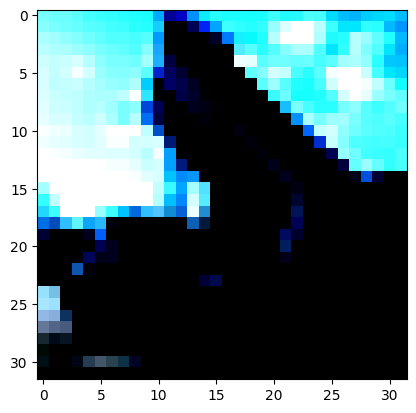

In [ ]:
# Pick a random image index (e.g., 50)
img, label = testset[50]
plt.imshow(img.permute(1, 2, 0).clamp(0, 1))

# Get prediction
predicted_label = predict_image(img, model)
actual_label = classes[label]

print(f'Actual: {actual_label}, Predicted: {predicted_label}')

In [ ]:
torch.save(model.state_dict(), 'cifar10-resnet9.pth')
from google.colab import files
files.download('cifar10-resnet9.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Set model to evaluation mode
model.eval()

correct = 0
total = 0

# 2. Disable gradient calculation for speed and memory efficiency
with torch.no_grad():
    for images, labels in testloader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Get model predictions
        outputs = model(images)

        # Pick the class with the highest score
        _, predicted = torch.max(outputs.data, 1)

        # Update counts
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

# 3. Calculate and print final percentage
final_acc = 100 * correct / total
print(f'{final_acc:.2f}%')

91.76%


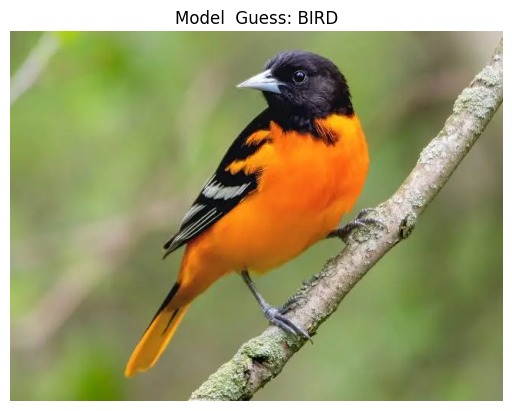

 bird 


In [ ]:
from PIL import Image
import requests
from io import BytesIO


url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcR4dbCwIwhQomEhhv72AeVtuYmwWk9u3nUtJXaSw-r8Mx8DAgrjiql6ykr9JS4cK-8UtEQ8iwLNNQekONiro-vDSfjNVlDxSZjk5DvUg30&s=10"


response = requests.get(url)
img = Image.open(BytesIO(response.content)).convert('RGB')


preprocess = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

img_tensor = preprocess(img).unsqueeze(0).to(device)


model.eval()
with torch.no_grad():
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    result = classes[predicted[0].item()]

# 5. Result dikhao
plt.imshow(img)
plt.title(f"Model  Guess: {result.upper()}")
plt.axis('off')
plt.show()

print(f" {result} ")